# E-Commerce Product Analytics
## SQL-based Funnel, Pre-purchase, and Cohort Retention Analysis


### Objective
Identify conversion bottlenecks and early churn patterns using event log data, and translate findings into actionable product improvement ideas.

## 1. Business Context

In e-commerce, high traffic does not always lead to high conversion.  
This project focuses on two business problems:

- Users drop off before adding products to cart
- Many users do not return after their first interaction

The goal is to identify where friction occurs and which KPIs should be prioritized for improvement.

## 2. Analysis Questions

1. Where is the biggest drop-off in the funnel?
2. What behavior patterns appear before purchase?
3. How quickly does retention decline after first interaction?
4. What actions can improve conversion and retention?

In [1]:
!pip install duckdb -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Data Preparation

This section prepares the sampled event log data for scalable SQL-based analysis.

In [3]:
file_path = "/content/drive/MyDrive/kaggle_data/2019-Nov.csv"
sample_path = "/content/drive/MyDrive/kaggle_data/2019-Nov-sample.csv"

In [ ]:
# 1) 일부만 추출하여 분석에 사용.
chunks = pd.read_csv(file_path, chunksize=500000)

df_list = []

for chunk in chunks:
    sample_size = min(len(chunk), 10000)
    df_list.append(chunk.sample(sample_size, random_state=42))

df = pd.concat(df_list, ignore_index=True)

print(df.shape)

(1351979, 9)


In [7]:
df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

In [8]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1351979 entries, 0 to 1351978
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   event_time     1351979 non-null  object 
 1   event_type     1351979 non-null  object 
 2   product_id     1351979 non-null  int64  
 3   category_id    1351979 non-null  int64  
 4   category_code  912939 non-null   object 
 5   brand          1167673 non-null  object 
 6   price          1351979 non-null  float64
 7   user_id        1351979 non-null  int64  
 8   user_session   1351978 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 92.8+ MB


,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,439040
brand,184306
price,0
user_id,0
user_session,1


In [9]:
# 2) 사용할 컬럼만 남기고 삭제
use_cols = [
    "event_time",
    "event_type",
    "product_id",
    "category_code",
    "price",
    "user_id",
    "user_session"
]

df = df[use_cols].copy()
df.head()

,event_time,event_type,product_id,category_code,price,user_id,user_session
0,2019-11-01 03:57:20 UTC,view,3700800,appliances.environment.vacuum,128.68,561394540,0d82ce6c-c81f-475d-a977-723d39e84585
1,2019-11-01 05:27:02 UTC,view,1003306,electronics.smartphone,577.89,544828613,e12cc5db-8914-4c34-a52a-c5d70691cb1f
2,2019-11-01 04:33:55 UTC,view,1307356,computers.notebook,360.11,557773679,1c0123bb-c0ad-4267-9b4b-f8a1e0efc7d6
3,2019-11-01 04:26:38 UTC,view,1004159,electronics.smartphone,1253.09,536305001,0f0255ed-527d-4f68-b821-70a7d2939c9f
4,2019-11-01 08:08:45 UTC,view,1005160,electronics.smartphone,212.08,540186874,5e40c1c7-ef4f-4b03-b5d9-100425eae5fe


In [11]:
# 3) 날짜 형변환
df["event_time"] = pd.to_datetime(df["event_time"])
df.head()

,event_time,event_type,product_id,category_code,price,user_id,user_session
0,2019-11-01 03:57:20+00:00,view,3700800,appliances.environment.vacuum,128.68,561394540,0d82ce6c-c81f-475d-a977-723d39e84585
1,2019-11-01 05:27:02+00:00,view,1003306,electronics.smartphone,577.89,544828613,e12cc5db-8914-4c34-a52a-c5d70691cb1f
2,2019-11-01 04:33:55+00:00,view,1307356,computers.notebook,360.11,557773679,1c0123bb-c0ad-4267-9b4b-f8a1e0efc7d6
3,2019-11-01 04:26:38+00:00,view,1004159,electronics.smartphone,1253.09,536305001,0f0255ed-527d-4f68-b821-70a7d2939c9f
4,2019-11-01 08:08:45+00:00,view,1005160,electronics.smartphone,212.08,540186874,5e40c1c7-ef4f-4b03-b5d9-100425eae5fe


In [12]:

# 4) 기본 확인
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df["event_type"].value_counts())


                 event_time event_type  product_id  \
0 2019-11-01 03:57:20+00:00       view     3700800   
1 2019-11-01 05:27:02+00:00       view     1003306   
2 2019-11-01 04:33:55+00:00       view     1307356   
3 2019-11-01 04:26:38+00:00       view     1004159   
4 2019-11-01 08:08:45+00:00       view     1005160   

                   category_code    price    user_id  \
0  appliances.environment.vacuum   128.68  561394540   
1         electronics.smartphone   577.89  544828613   
2             computers.notebook   360.11  557773679   
3         electronics.smartphone  1253.09  536305001   
4         electronics.smartphone   212.08  540186874   

                           user_session  
0  0d82ce6c-c81f-475d-a977-723d39e84585  
1  e12cc5db-8914-4c34-a52a-c5d70691cb1f  
2  1c0123bb-c0ad-4267-9b4b-f8a1e0efc7d6  
3  0f0255ed-527d-4f68-b821-70a7d2939c9f  
4  5e40c1c7-ef4f-4b03-b5d9-100425eae5fe  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1351979 entries, 0 to 1351978
Data c

In [13]:
# 5) 샘플 저장
df.to_csv(sample_path, index=False)
print("saved:", sample_path)

saved: /content/drive/MyDrive/kaggle_data/2019-Nov-sample.csv


In [14]:
df = pd.read_csv("/content/drive/MyDrive/kaggle_data/2019-Nov-sample.csv")
df["event_time"] = pd.to_datetime(df["event_time"])

In [15]:
df["event_time"].min(), df["event_time"].max()

(Timestamp('2019-11-01 00:00:01+0000', tz='UTC'),
 Timestamp('2019-11-30 23:59:59+0000', tz='UTC'))

## 4. Funnel Analysis

Measure conversion across the main journey:
view → cart → purchase

In [16]:
funnel_sql = """
WITH base AS (
    SELECT
        event_type,
        COUNT(DISTINCT user_id) AS unique_users
    FROM df
    WHERE event_type IN ('view', 'cart', 'purchase')
    GROUP BY event_type
),
ordered AS (
    SELECT
        event_type,
        unique_users,
        CASE
            WHEN event_type = 'view' THEN 1
            WHEN event_type = 'cart' THEN 2
            WHEN event_type = 'purchase' THEN 3
        END AS stage_order
    FROM base
)
SELECT
    event_type,
    unique_users,
    ROUND(
        unique_users * 100.0 /
        MAX(CASE WHEN event_type = 'view' THEN unique_users END) OVER (),
    2) AS overall_conversion,
    ROUND(
        unique_users * 100.0 /
        LAG(unique_users) OVER (ORDER BY stage_order),
    2) AS step_conversion_rate
FROM ordered
ORDER BY stage_order;
"""

funnel_result = duckdb.sql(funnel_sql).df()
funnel_result["step_conversion_rate"] = funnel_result["step_conversion_rate"].fillna("-")
funnel_result

,event_type,unique_users,overall_conversion,step_conversion_rate
0,view,738590,100.00,-
1,cart,55346,7.49,7.49
2,purchase,17267,2.34,31.2


In [17]:
view_users = funnel_result.loc[funnel_result["event_type"]=="view", "unique_users"].iloc[0]
cart_users = funnel_result.loc[funnel_result["event_type"]=="cart", "unique_users"].iloc[0]
purchase_users = funnel_result.loc[funnel_result["event_type"]=="purchase", "unique_users"].iloc[0]

view_to_cart = round(cart_users / view_users * 100, 2)
cart_to_purchase = round(purchase_users / cart_users * 100, 2)
view_to_purchase = round(purchase_users / view_users * 100, 2)

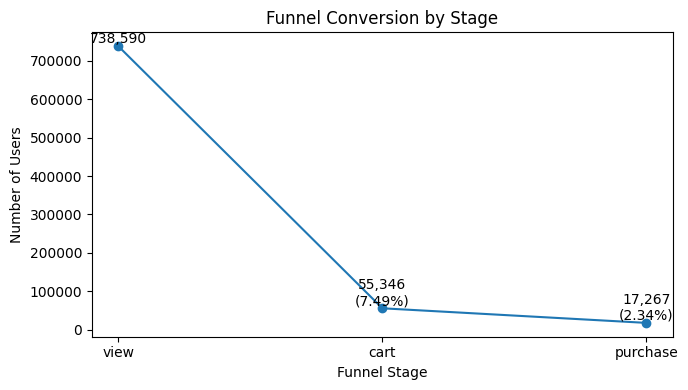

In [30]:
funnel_df = funnel_result.copy()
order = ["view", "cart", "purchase"]
funnel_df["event_type"] = pd.Categorical(funnel_df["event_type"], categories=order, ordered=True)
funnel_df = funnel_df.sort_values("event_type")

labels = [
    f"view\n{view_users:,}",
    f"cart\n{cart_users:,}\n({view_to_cart}%)",
    f"purchase\n{purchase_users:,}\n({view_to_purchase}%)"
]

plt.figure(figsize=(7,4))
plt.plot(funnel_df["event_type"], funnel_df["unique_users"], marker="o")
plt.title("Funnel Conversion by Stage")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Users")

for i, v in enumerate(funnel_df["unique_users"]):
    if i == 0:
        text = f"{v:,}"
    elif i == 1:
        text = f"{v:,}\n({view_to_cart}%)"
    else:
        text = f"{v:,}\n({view_to_purchase}%)"
    plt.text(i, v, text, ha="center", va="bottom")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/kaggle_data/outputs/funnel_conversion_by_stage.png", dpi=150)
plt.show()



## 4-1. Funnel Insight

The largest drop occurs between view and cart, suggesting that early-stage product interaction may be the main source of friction.

## 5. Pre-purchase Behavior Analysis

Examine which event patterns are most common before purchase.

In [24]:
pre_purchase_sql = """
WITH purchase_events AS (
    SELECT
        user_id,
        user_session,
        event_time AS purchase_time
    FROM df
    WHERE event_type = 'purchase'
),
previous_events AS (
    SELECT
        p.user_id,
        p.user_session,
        p.purchase_time,
        d.event_type,
        d.event_time,
        ROW_NUMBER() OVER (
            PARTITION BY p.user_id, p.user_session, p.purchase_time
            ORDER BY d.event_time DESC
        ) AS rn
    FROM purchase_events p
    JOIN df d
      ON p.user_id = d.user_id
     AND p.user_session = d.user_session
     AND d.event_time < p.purchase_time
),
agg AS (
    SELECT
        event_type AS previous_event,
        COUNT(*) AS transition_count
    FROM previous_events
    WHERE rn = 1
    GROUP BY 1
)
SELECT
    previous_event,
    transition_count,
    ROUND(
        transition_count * 100.0 / SUM(transition_count) OVER (),
    2) AS ratio
FROM agg
ORDER BY transition_count DESC
"""

pre_purchase_result = duckdb.sql(pre_purchase_sql).df()
pre_purchase_result

,previous_event,transition_count,ratio
0,view,1591,71.38
1,cart,564,25.30
2,purchase,74,3.32


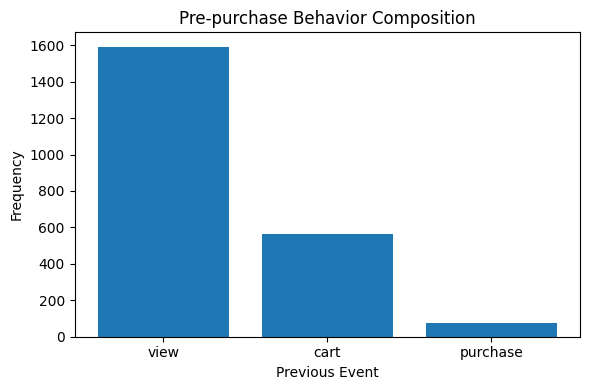

In [32]:
plt.figure(figsize=(6,4))
plt.bar(pre_purchase_result["previous_event"], pre_purchase_result["transition_count"])
plt.title("Pre-purchase Behavior Composition")
plt.xlabel("Previous Event")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/kaggle_data/outputs/pre_purchase_behavior_composition.png", dpi=150)
plt.show()


## 5-1. Behavior Insight

Product views dominate the pre-purchase flow, which implies that product page experience strongly influences conversion.

## 6. Weekly Cohort Retention

Track whether users return after their first interaction and how retention changes over time.

In [26]:
weekly_cohort_sql = """
WITH base AS (
    SELECT
        user_id,
        DATE_TRUNC('week', event_time) AS event_week
    FROM df
),
first_week AS (
    SELECT
        user_id,
        MIN(event_week) AS cohort_week
    FROM base
    GROUP BY user_id
),
cohort_activity AS (
    SELECT
        b.user_id,
        f.cohort_week,
        b.event_week,
        DATE_DIFF('week', f.cohort_week, b.event_week) AS week_number
    FROM base b
    JOIN first_week f
      ON b.user_id = f.user_id
),
cohort_counts AS (
    SELECT
        cohort_week,
        week_number,
        COUNT(DISTINCT user_id) AS active_users
    FROM cohort_activity
    GROUP BY 1, 2
),
cohort_size AS (
    SELECT
        cohort_week,
        COUNT(DISTINCT user_id) AS cohort_users
    FROM first_week
    GROUP BY 1
)
SELECT
    c.cohort_week,
    c.week_number,
    c.active_users,
    s.cohort_users,
    ROUND(100.0 * c.active_users / s.cohort_users, 2) AS retention_rate
FROM cohort_counts c
JOIN cohort_size s
  ON c.cohort_week = s.cohort_week
ORDER BY c.cohort_week, c.week_number
"""


# 주 시작이 월요일 기준, DATE_TRUNC('week', event_time)

weekly_cohort_result = duckdb.sql(weekly_cohort_sql).df()
weekly_cohort_result.head(20)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,cohort_week,week_number,active_users,cohort_users,retention_rate
0,2019-10-28 00:00:00+00:00,0,73268,73268,100.00
1,2019-10-28 00:00:00+00:00,1,12634,73268,17.24
2,2019-10-28 00:00:00+00:00,2,16575,73268,22.62
3,2019-10-28 00:00:00+00:00,3,7418,73268,10.12
4,2019-10-28 00:00:00+00:00,4,6188,73268,8.45
5,2019-11-04 00:00:00+00:00,0,178235,178235,100.00
6,2019-11-04 00:00:00+00:00,1,38215,178235,21.44
7,2019-11-04 00:00:00+00:00,2,15589,178235,8.75
8,2019-11-04 00:00:00+00:00,3,12819,178235,7.19
9,2019-11-11 00:00:00+00:00,0,285572,285572,100.00


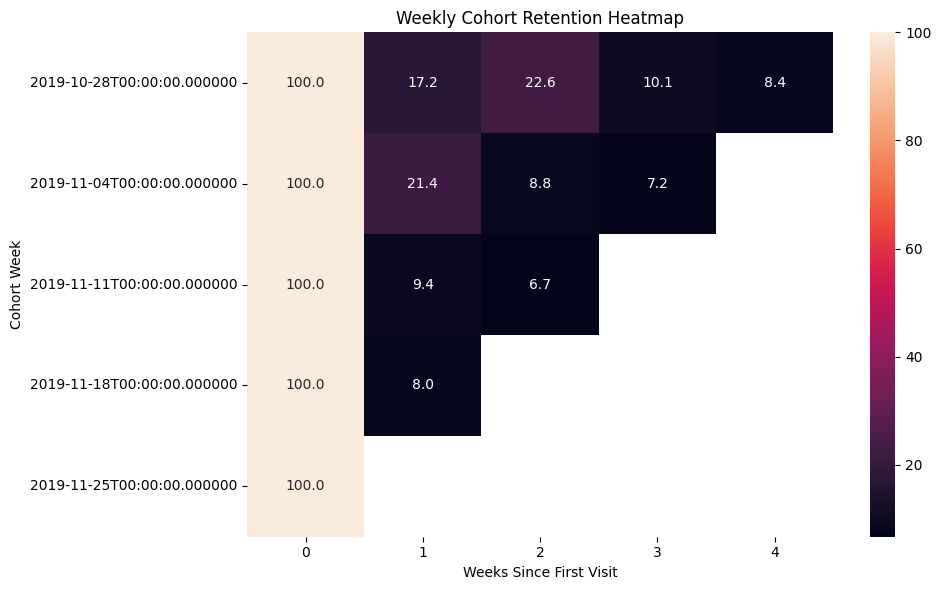

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

cohort_pivot = weekly_cohort_result.pivot(
    index="cohort_week",
    columns="week_number",
    values="retention_rate"
)

plt.figure(figsize=(10,6))
sns.heatmap(cohort_pivot, annot=True, fmt=".1f")

plt.title("Weekly Cohort Retention Heatmap")
plt.ylabel("Cohort Week")
plt.xlabel("Weeks Since First Visit")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/kaggle_data/outputs/weekly_cohort_retention_heatmap.png", dpi=150)
plt.show()

## 6-1. Retention Insight

Most cohorts show steep drop-off after week 1, indicating weak early retention.

## 7. Business Recommendations

### Recommendation 1
Run A/B tests on product page layout and CTA placement to improve view-to-cart conversion.

### Recommendation 2
Design first-week re-engagement tactics to improve early retention.

### Recommendation 3
Build a lightweight monitoring dashboard for funnel and retention KPIs.